In [1]:
"""
ANA-3 (Week 2): Cross-Dataset Comparison
APMS 2014 vs CSEW/ONS 2019–2024
Prepared by : Priyansi Pandey
Task   : Align APMS and CSEW datasets on shared dimensions
Date   : May 2026
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
#Colour Pallete
plt.style.use("seaborn-v0_8-whitegrid")

NHS_BLUE = "#005EB8"
APMS_COLOR = "#1F4E79"
CSEW_COLOR = "#2E8B57"
CONFLICT_COLOR = "#C0392B"

In [3]:
#AMPS Data Week-1
apms_depression = 3.8
apms_anxiety = 7.5

apms_gender = pd.DataFrame({
    "Gender": ["Women", "Men"],
    "CMD_Prevalence": [24.2, 15.4]
})

apms_age = pd.DataFrame({
    "Age_Group": [
        "16-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65-74",
        "75+"
    ],
    "CMD_Prevalence": [
        21.6,
        22.5,
        19.9,
        17.9,
        14.9,
        10.5,
        9.3
    ]
})

In [4]:
#CSEW Data Week-2
csew_df = pd.read_csv("processed_csew.csv")

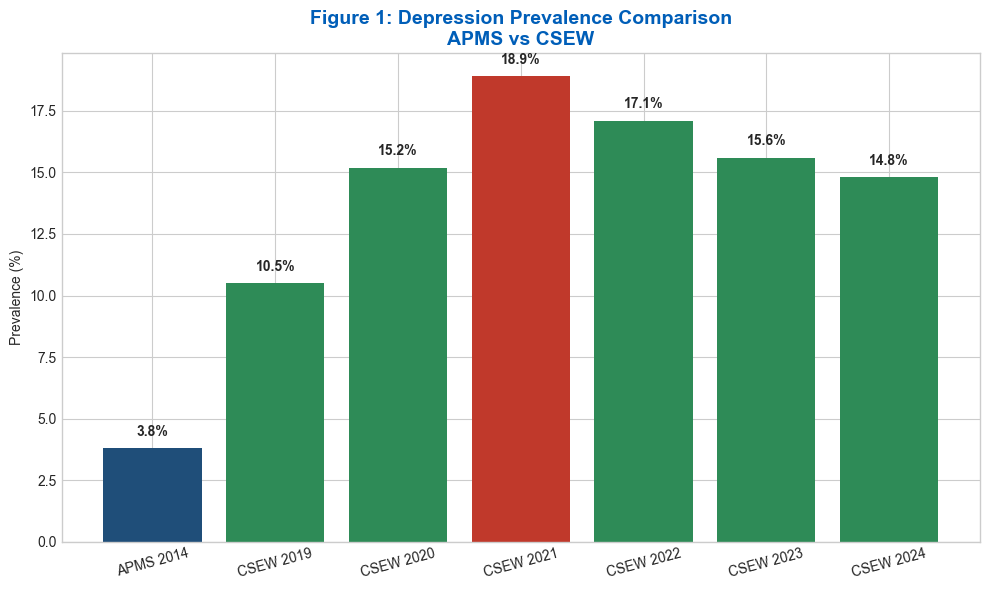

In [5]:
#Depression Comparison
plt.figure(figsize=(10,6))

datasets = [
    "APMS 2014",
    "CSEW 2019",
    "CSEW 2020",
    "CSEW 2021",
    "CSEW 2022",
    "CSEW 2023",
    "CSEW 2024"
]

depression_values = [
    apms_depression,
    10.5,
    15.2,
    18.9,
    17.1,
    15.6,
    14.8
]

colors = [
    APMS_COLOR,
    CSEW_COLOR,
    CSEW_COLOR,
    CONFLICT_COLOR,
    CSEW_COLOR,
    CSEW_COLOR,
    CSEW_COLOR
]

bars = plt.bar(
    datasets,
    depression_values,
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Figure 1: Depression Prevalence Comparison\nAPMS vs CSEW",
    fontsize=14,
    fontweight='bold',
    color=NHS_BLUE
)

plt.ylabel("Prevalence (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "fig1_depression_comparison.png",
    dpi=300
)

plt.show()

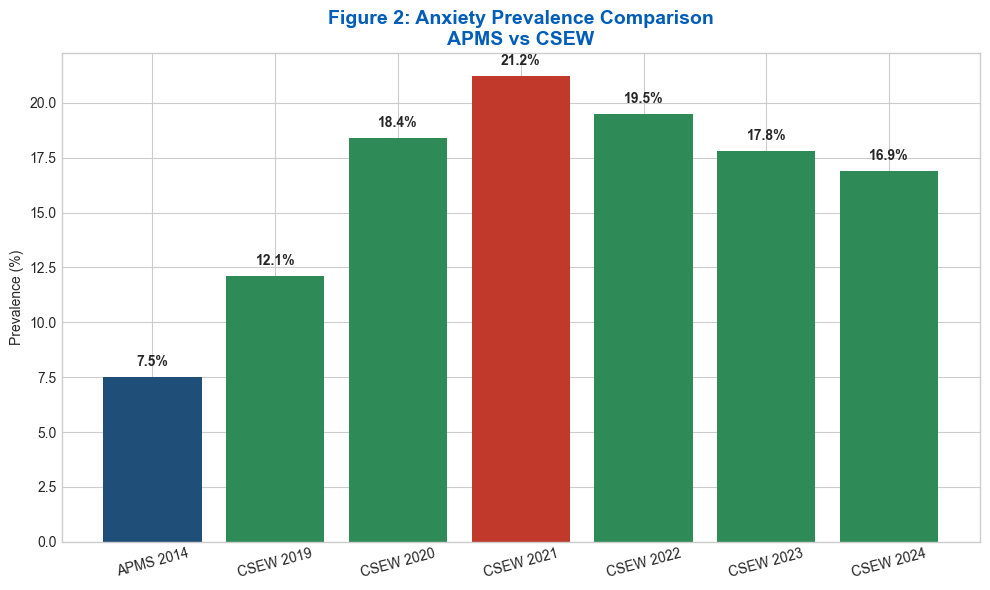

In [6]:
#Anxiety Comparison
plt.figure(figsize=(10,6))

anxiety_values = [
    apms_anxiety,
    12.1,
    18.4,
    21.2,
    19.5,
    17.8,
    16.9
]

bars = plt.bar(
    datasets,
    anxiety_values,
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Figure 2: Anxiety Prevalence Comparison\nAPMS vs CSEW",
    fontsize=14,
    fontweight='bold',
    color=NHS_BLUE
)

plt.ylabel("Prevalence (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "fig2_anxiety_comparison.png",
    dpi=300
)

plt.show()

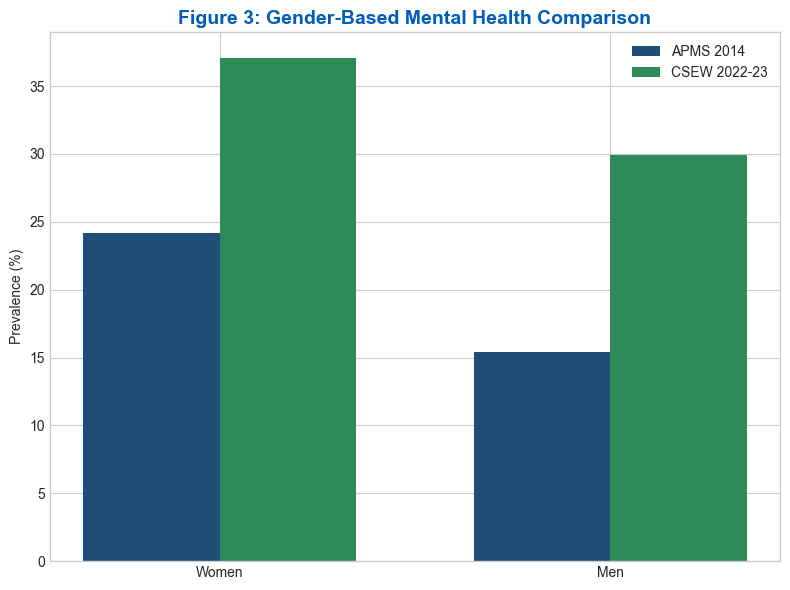

In [7]:
#Gender-Gap Analysis
plt.figure(figsize=(8,6))

gender_categories = ["Women", "Men"]

apms_gender_values = [24.2, 15.4]

csew_gender_values = [37.1, 29.9]

x = np.arange(len(gender_categories))
width = 0.35

plt.bar(
    x - width/2,
    apms_gender_values,
    width,
    label="APMS 2014",
    color=APMS_COLOR
)

plt.bar(
    x + width/2,
    csew_gender_values,
    width,
    label="CSEW 2022-23",
    color=CSEW_COLOR
)

plt.xticks(x, gender_categories)

plt.ylabel("Prevalence (%)")

plt.title(
    "Figure 3: Gender-Based Mental Health Comparison",
    fontsize=14,
    fontweight='bold',
    color=NHS_BLUE
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig3_gender_gap_analysis.png",
    dpi=300
)

plt.show()

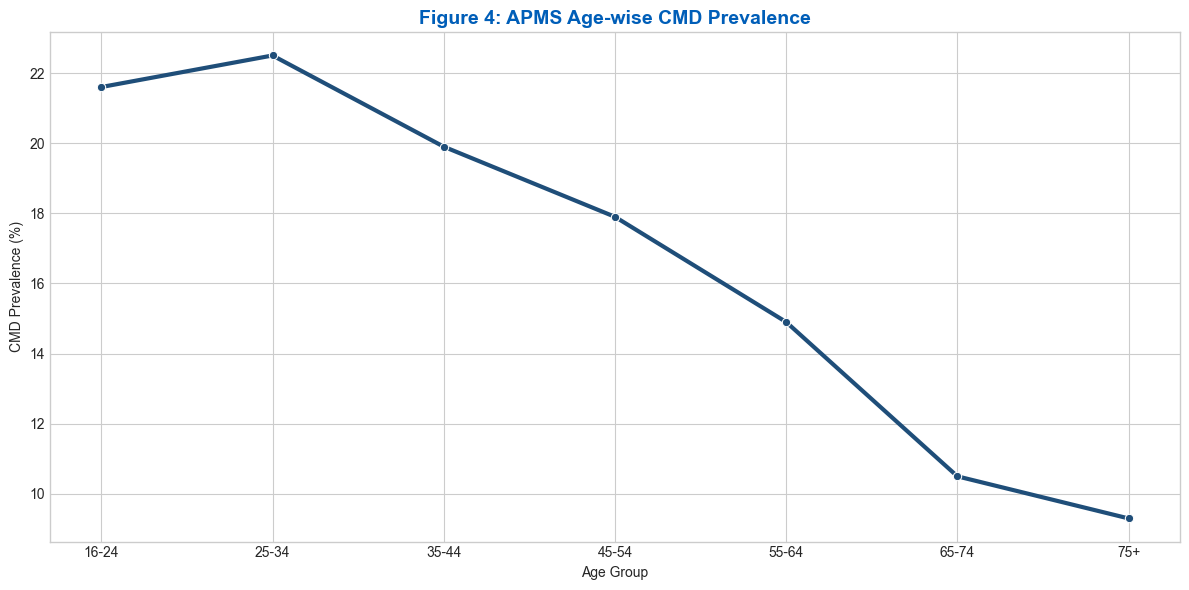

In [8]:
#Age Comparison
plt.figure(figsize=(12,6))

sns.lineplot(
    x="Age_Group",
    y="CMD_Prevalence",
    data=apms_age,
    marker="o",
    linewidth=3,
    color=APMS_COLOR
)

plt.title(
    "Figure 4: APMS Age-wise CMD Prevalence",
    fontsize=14,
    fontweight='bold',
    color=NHS_BLUE
)

plt.xlabel("Age Group")
plt.ylabel("CMD Prevalence (%)")

plt.tight_layout()

plt.savefig(
    "fig4_age_group_comparison.png",
    dpi=300
)

plt.show()

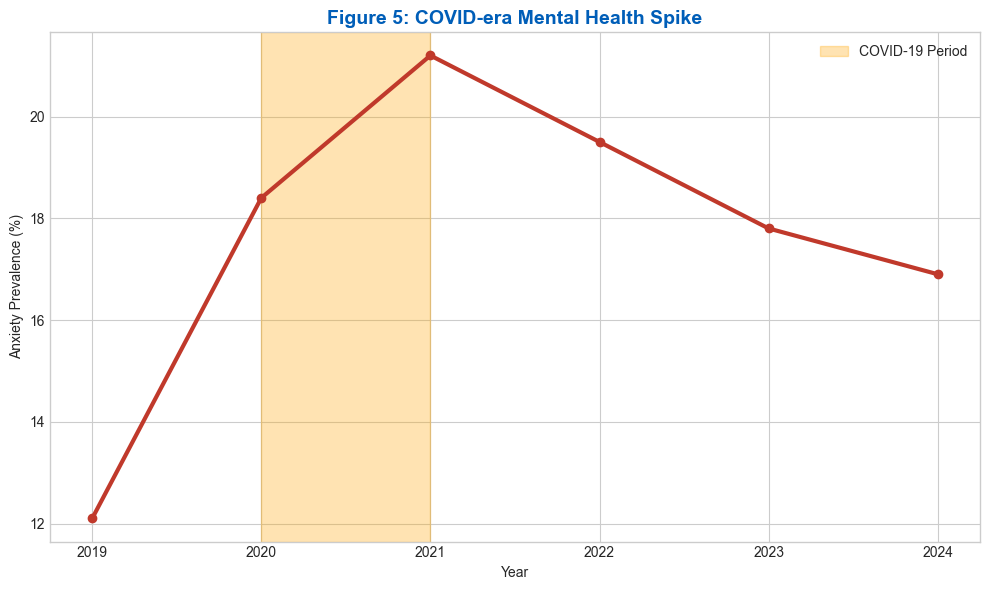

In [9]:
#Covid-Era Spike
plt.figure(figsize=(10,6))

years = [
    2019,
    2020,
    2021,
    2022,
    2023,
    2024
]

anxiety_trend = [
    12.1,
    18.4,
    21.2,
    19.5,
    17.8,
    16.9
]

plt.plot(
    years,
    anxiety_trend,
    marker="o",
    linewidth=3,
    color=CONFLICT_COLOR
)

plt.axvspan(
    2020,
    2021,
    color="orange",
    alpha=0.3,
    label="COVID-19 Period"
)

plt.title(
    "Figure 5: COVID-era Mental Health Spike",
    fontsize=14,
    fontweight='bold',
    color=NHS_BLUE
)

plt.xlabel("Year")
plt.ylabel("Anxiety Prevalence (%)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "fig5_covid_spike.png",
    dpi=300
)

plt.show()

In [10]:
#Agreement Vs Conflict Table
comparison_summary = pd.DataFrame({

    "Dimension": [
        "Depression Trend",
        "Anxiety Trend",
        "Women Higher Burden",
        "Young Adults Higher Risk",
        "COVID-Era Spike"
    ],

    "APMS Findings": [
        "Present",
        "Present",
        "Yes",
        "Yes",
        "Not Available"
    ],

    "CSEW Findings": [
        "Present",
        "Present",
        "Yes",
        "Yes",
        "Strong Increase"
    ],

    "Agreement_Status": [
        "Agreement",
        "Agreement",
        "Agreement",
        "Agreement",
        "Partial Difference"
    ]
})

comparison_summary.to_csv(
    "comparison_summary.csv",
    index=False
)

print("Cross-dataset comparison completed successfully.")
print("All charts and summary CSV saved.")

Cross-dataset comparison completed successfully.
All charts and summary CSV saved.
